In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the HPO results dataset
with open('../data/datasets/HHFW-NSTX/combined_hpo_results_corr2.pkl', 'rb') as f:
    df = pickle.load(f)


df.info()


/var/folders/7f/sdj0z28s4812sr3yx4qgkxq8xv5p43/T/ipykernel_98151/3313086693.py:9: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   study                 300 non-null    object         
 1   number                300 non-null    int64          
 2   mse                   300 non-null    float64        
 3   r2                    300 non-null    float64        
 4   datetime_start        300 non-null    datetime64[ns] 
 5   datetime_complete     300 non-null    datetime64[ns] 
 6   duration              300 non-null    timedelta64[ns]
 7   params_activation_fn  300 non-null    object         
 8   params_batch_size     300 non-null    int64          
 9   params_dropout_rate   300 non-null    float64        
 10  params_hidden_size    300 non-null    int64          
 11  params_learning_rate  300 non-null    float64        
 12  params_num_layers     300 non-null    int64          
 13  state

In [3]:
df.duration 

0     0 days 00:00:01.454781
1     0 days 00:00:03.224653
2     0 days 00:00:01.477278
3     0 days 00:00:05.595817
4     0 days 00:00:03.208633
               ...          
295   0 days 00:00:10.311123
296   0 days 00:00:05.024846
297   0 days 00:00:11.458810
298   0 days 00:00:07.251459
299   0 days 00:00:05.773744
Name: duration, Length: 300, dtype: timedelta64[ns]

In [4]:
minutes, seconds = divmod(df.duration.sum().total_seconds(),60)
print(f"Total time: {int(minutes)} minutes and {seconds:.2f} seconds")

Total time: 27 minutes and 37.05 seconds


In [10]:
df.study[list([0,50,100,150,200,250])]
total_per_model = df.groupby('study')['duration'].sum()
for idx, t in total_per_model.items():
    minutes, seconds = divmod(t.total_seconds(), 60)
    print(f"Total time for model {idx}: {int(minutes)} minutes and {seconds:.2f} seconds")

Total time for model BoTorch_mse: 6 minutes and 19.28 seconds
Total time for model BoTorch_r2: 4 minutes and 55.37 seconds
Total time for model Random_mse: 4 minutes and 0.81 seconds
Total time for model Random_r2: 4 minutes and 2.36 seconds
Total time for model TPE_mse: 3 minutes and 54.39 seconds
Total time for model TPE_r2: 4 minutes and 24.84 seconds


In [3]:
# =============================================================================
# DATASET GLOSSARY AND ANALYZER
# =============================================================================

print("📊 HYPERPARAMETER OPTIMIZATION DATASET ANALYZER")
print("="*80)

# =============================================================================
# DATASET OVERVIEW
# =============================================================================
print("\n🔍 DATASET OVERVIEW:")
print("-" * 50)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Data Types:")
for dtype in df.dtypes.value_counts().items():
    print(f"  {dtype[1]} columns of type '{dtype[0]}'")

print(f"\nMissing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing values detected")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count} missing ({count/len(df)*100:.1f}%)")

# =============================================================================
# COLUMN GLOSSARY
# =============================================================================
print(f"\n📚 COLUMN GLOSSARY:")
print("-" * 50)

# Define column descriptions
column_glossary = {
    'study': 'Study identifier combining sampler method and optimization target (e.g., TPE_mse, BoTorch_r2)',
    'number': 'Sequential trial number within each study (0-based indexing)',
    'mse': 'Mean Squared Error - primary regression metric (lower is better)',
    'r2': 'Coefficient of Determination (R²) - explained variance ratio (higher is better, range typically 0-1)',
    'datetime_start': 'Timestamp when the trial execution started',
    'datetime_complete': 'Timestamp when the trial execution completed',
    'duration': 'Trial execution time (datetime_complete - datetime_start)',
    'params_activation_fn': 'Neural network activation function (e.g., relu, tanh, sigmoid)',
    'params_batch_size': 'Mini-batch size for training (number of samples per gradient update)',
    'params_dropout_rate': 'Dropout regularization rate (probability of setting neurons to zero)',
    'params_hidden_size': 'Number of neurons in hidden layers',
    'params_learning_rate': 'Optimizer learning rate (step size for gradient descent)',
    'params_num_layers': 'Number of hidden layers in the neural network',
    'state': 'Trial completion status (e.g., COMPLETE, FAIL, PRUNED)'
}

for col in df.columns:
    if col in column_glossary:
        print(f"\n{col}:")
        print(f"  Description: {column_glossary[col]}")
        print(f"  Type: {df[col].dtype}")
        
        if df[col].dtype in ['object', 'category']:
            unique_vals = df[col].unique()
            print(f"  Unique Values ({len(unique_vals)}): {list(unique_vals)}")
        else:
            print(f"  Range: {df[col].min()} to {df[col].max()}")
            if col in ['mse', 'r2']:
                print(f"  Mean: {df[col].mean():.6f}")
                print(f"  Std: {df[col].std():.6f}")

# =============================================================================
# STUDY COMPOSITION ANALYSIS
# =============================================================================
print(f"\n🧪 STUDY COMPOSITION ANALYSIS:")
print("-" * 50)

study_info = {
    'TPE_mse': {
        'method': 'Tree-structured Parzen Estimator',
        'target': 'Mean Squared Error minimization',
        'description': 'Bayesian optimization using TPE sampler to minimize MSE'
    },
    'TPE_r2': {
        'method': 'Tree-structured Parzen Estimator', 
        'target': 'R² coefficient maximization',
        'description': 'Bayesian optimization using TPE sampler to maximize R²'
    },
    'BoTorch_mse': {
        'method': 'Bayesian Optimization with Torch',
        'target': 'Mean Squared Error minimization',
        'description': 'Gaussian Process-based Bayesian optimization to minimize MSE'
    },
    'BoTorch_r2': {
        'method': 'Bayesian Optimization with Torch',
        'target': 'R² coefficient maximization', 
        'description': 'Gaussian Process-based Bayesian optimization to maximize R²'
    }
}

for study in df['study'].unique():
    study_data = df[df['study'] == study]
    info = study_info.get(study, {})
    
    print(f"\n{study} ({len(study_data)} trials):")
    if info:
        print(f"  Method: {info['method']}")
        print(f"  Target: {info['target']}")
        print(f"  Description: {info['description']}")
    
    print(f"  Performance Summary:")
    print(f"    Best R²: {study_data['r2'].max():.6f}")
    print(f"    Best MSE: {study_data['mse'].min():.8f}")
    print(f"    Avg R²: {study_data['r2'].mean():.6f} ± {study_data['r2'].std():.6f}")
    print(f"    Avg MSE: {study_data['mse'].mean():.8f} ± {study_data['mse'].std():.8f}")

# =============================================================================
# HYPERPARAMETER SPACE ANALYSIS
# =============================================================================
print(f"\n⚙️ HYPERPARAMETER SPACE ANALYSIS:")
print("-" * 50)

param_columns = [col for col in df.columns if col.startswith('params_')]
print(f"Hyperparameter dimensions: {len(param_columns)}")

for param in param_columns:
    param_name = param.replace('params_', '')
    print(f"\n{param_name}:")
    
    if df[param].dtype in ['object', 'category']:
        value_counts = df[param].value_counts()
        print(f"  Type: Categorical ({len(value_counts)} unique values)")
        print(f"  Distribution:")
        for val, count in value_counts.items():
            print(f"    {val}: {count} trials ({count/len(df)*100:.1f}%)")
    else:
        print(f"  Type: Numerical")
        print(f"  Range: {df[param].min()} to {df[param].max()}")
        print(f"  Mean: {df[param].mean():.6f}")
        print(f"  Unique values: {df[param].nunique()}")

# =============================================================================
# PERFORMANCE METRICS ANALYSIS
# =============================================================================
print(f"\n📈 PERFORMANCE METRICS ANALYSIS:")
print("-" * 50)

print("R² Score Analysis:")
print(f"  Overall range: {df['r2'].min():.6f} to {df['r2'].max():.6f}")
print(f"  Mean: {df['r2'].mean():.6f}")
print(f"  Median: {df['r2'].median():.6f}")
print(f"  Standard deviation: {df['r2'].std():.6f}")

negative_r2_count = (df['r2'] < 0).sum()
if negative_r2_count > 0:
    print(f"  ⚠️  Negative R² values: {negative_r2_count} trials ({negative_r2_count/len(df)*100:.1f}%)")
    print(f"      Note: Negative R² indicates model performs worse than predicting the mean")

print(f"\nMSE Analysis:")
print(f"  Overall range: {df['mse'].min():.8f} to {df['mse'].max():.8f}")
print(f"  Mean: {df['mse'].mean():.8f}")
print(f"  Median: {df['mse'].median():.8f}")
print(f"  Standard deviation: {df['mse'].std():.8f}")

# Log scale analysis for MSE
import numpy as np
log_mse_range = np.log10(df['mse'].max()) - np.log10(df['mse'].min())
print(f"  Log scale span: {log_mse_range:.1f} orders of magnitude")

# =============================================================================
# OPTIMIZATION INSIGHTS
# =============================================================================
print(f"\n🎯 OPTIMIZATION INSIGHTS:")
print("-" * 50)

print("Sampler Comparison:")
for sampler in ['TPE', 'BoTorch']:
    sampler_data = df[df['study'].str.contains(sampler)]
    print(f"  {sampler} ({len(sampler_data)} trials):")
    print(f"    Avg R²: {sampler_data['r2'].mean():.6f}")
    print(f"    Avg MSE: {sampler_data['mse'].mean():.8f}")
    print(f"    Best R²: {sampler_data['r2'].max():.6f}")
    print(f"    Best MSE: {sampler_data['mse'].min():.8f}")

print(f"\nOptimization Target Comparison:")
for target in ['mse', 'r2']:
    target_data = df[df['study'].str.contains(target)]
    print(f"  {target.upper()} optimization ({len(target_data)} trials):")
    print(f"    Avg R²: {target_data['r2'].mean():.6f}")
    print(f"    Avg MSE: {target_data['mse'].mean():.8f}")

# =============================================================================
# DATA QUALITY ASSESSMENT
# =============================================================================
print(f"\n✅ DATA QUALITY ASSESSMENT:")
print("-" * 50)

quality_score = 100

# Check for missing values
if df.isnull().sum().sum() == 0:
    print("✅ Completeness: No missing values")
else:
    missing_pct = df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100
    quality_score -= missing_pct
    print(f"⚠️  Completeness: {missing_pct:.1f}% missing values")

# Check for duplicate trials
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("✅ Uniqueness: No duplicate rows")
else:
    quality_score -= duplicates / len(df) * 10
    print(f"⚠️  Uniqueness: {duplicates} duplicate rows")

# Check for reasonable value ranges
if df['r2'].min() >= -10 and df['r2'].max() <= 1:
    print("✅ Validity: R² values in reasonable range")
else:
    quality_score -= 10
    print("⚠️  Validity: R² values outside expected range")

if df['mse'].min() >= 0:
    print("✅ Validity: MSE values non-negative")
else:
    quality_score -= 10
    print("⚠️  Validity: Negative MSE values detected")

# Check for balanced studies
study_sizes = df['study'].value_counts()
if study_sizes.std() / study_sizes.mean() < 0.1:
    print("✅ Balance: Studies have similar sample sizes")
else:
    quality_score -= 5
    print("⚠️  Balance: Uneven study sizes")

print(f"\nOverall Data Quality Score: {quality_score:.1f}/100")

print(f"\n{'='*80}")
print("📋 DATASET SUMMARY:")
print(f"• {len(df)} hyperparameter optimization trials")
print(f"• {len(df['study'].unique())} optimization studies")
print(f"• {len(param_columns)} hyperparameter dimensions")
print(f"• Complete performance metrics (R², MSE)")
print(f"• Ready for comparative analysis and modeling")
print(f"{'='*80}")

📊 HYPERPARAMETER OPTIMIZATION DATASET ANALYZER

🔍 DATASET OVERVIEW:
--------------------------------------------------
Dataset Shape: 300 rows × 14 columns
Memory Usage: 0.37 MB
Data Types:
  4 columns of type 'int64'
  4 columns of type 'float64'
  3 columns of type 'object'
  2 columns of type 'datetime64[ns]'
  1 columns of type 'timedelta64[ns]'

Missing Values:
  ✅ No missing values detected

📚 COLUMN GLOSSARY:
--------------------------------------------------

study:
  Description: Study identifier combining sampler method and optimization target (e.g., TPE_mse, BoTorch_r2)
  Type: object
  Unique Values (6): ['TPE_mse', 'TPE_r2', 'BoTorch_mse', 'BoTorch_r2', 'Random_mse', 'Random_r2']

number:
  Description: Sequential trial number within each study (0-based indexing)
  Type: int64
  Range: 0 to 49

mse:
  Description: Mean Squared Error - primary regression metric (lower is better)
  Type: float64
  Range: 6.4583814491925295e-06 to 841347.8125
  Mean: 2804.746311
  Std: 48575.

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

🎨 Creating LaTeX-formatted hyperparameter optimization plot...
📊 Creating LaTeX-formatted plot for optimization methods


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

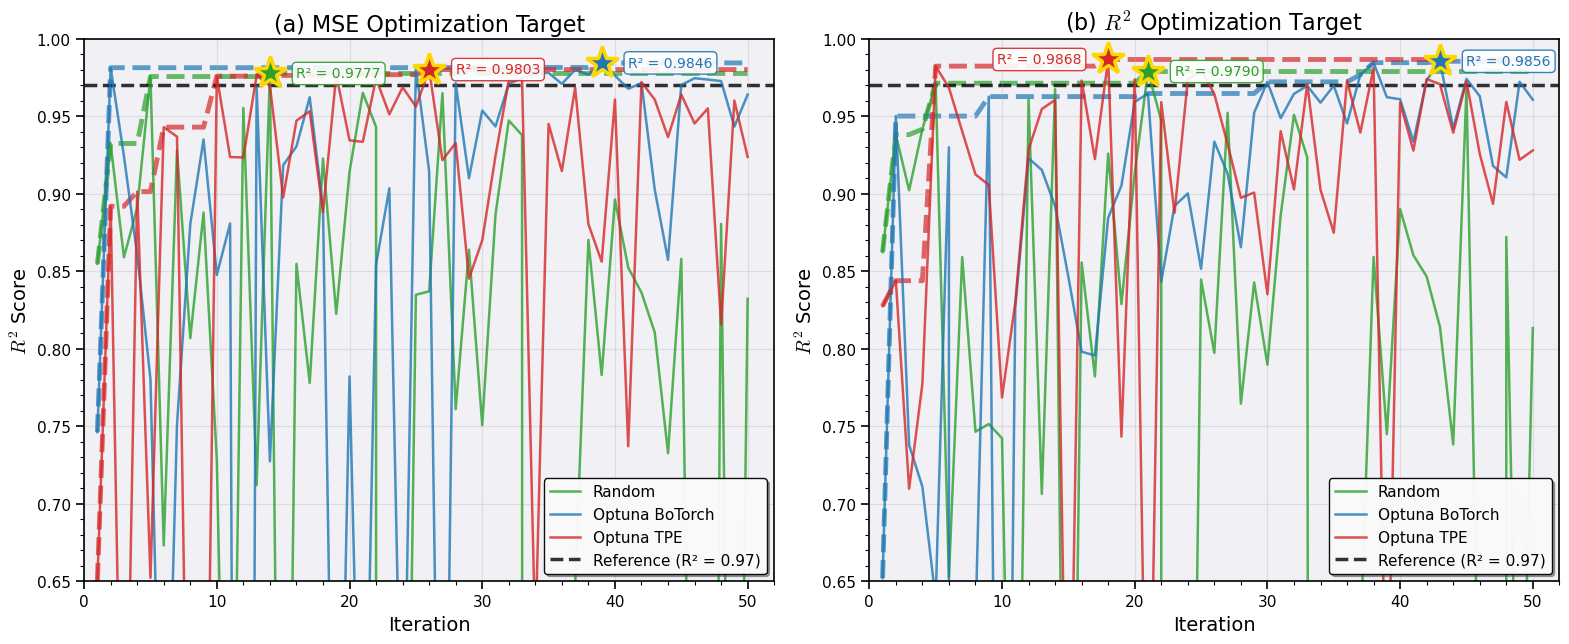

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following


✅ LaTeX-formatted TPE vs BoTorch comparison plot created!
🌟 Features:
   • LaTeX-style mathematical typography
   • Computer Modern font family
   • Professional grid and styling
   • Enhanced star markers with performance labels
   • Dual optimization target comparison
   • Publication-quality layout

📊 OPTIMIZATION PERFORMANCE SUMMARY:

MSE Optimization Target:
----------------------------------------
   TPE     : Max R² = 0.980273 at iter 26 | Final R² = 0.923899
   BoTorch : Max R² = 0.984574 at iter 39 | Final R² = 0.964108

R2 Optimization Target:
----------------------------------------
   TPE     : Max R² = 0.986774 at iter 18 | Final R² = 0.928092
   BoTorch : Max R² = 0.985604 at iter 43 | Final R² = 0.960811


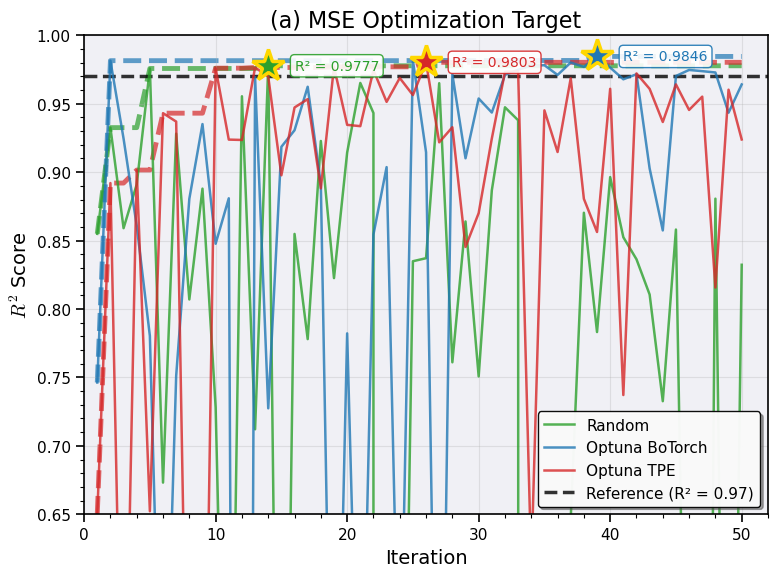

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

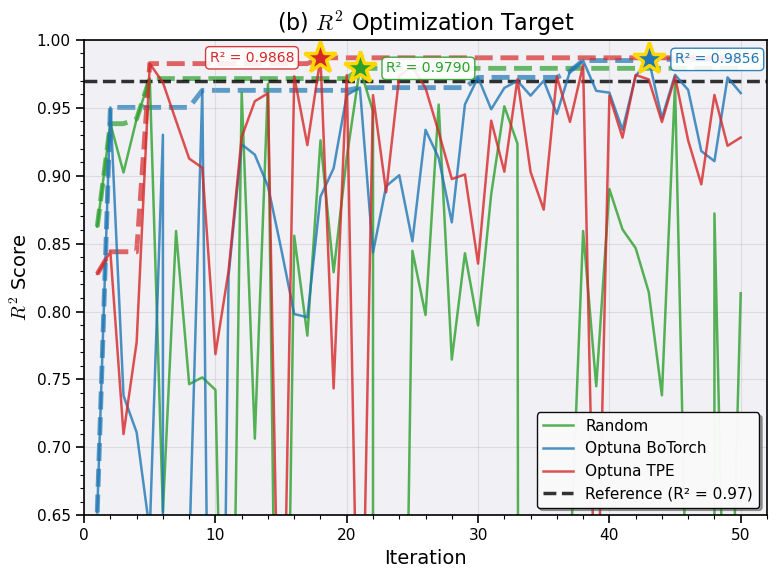

In [10]:
# =============================================================================
# LATEX-FORMATTED TPE VS BOTORCH CONVERGENCE PLOT
# =============================================================================

print("🎨 Creating LaTeX-formatted hyperparameter optimization plot...")
print("=" * 70)

import matplotlib as mpl

# Configure matplotlib for LaTeX-style rendering (matching reference style)
plt.rcParams.update({
    'text.usetex': False,  # Keep False to avoid LaTeX installation issues
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.titlesize': 20,
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
    'patch.linewidth': 0.8,
    'axes.grid': True,
    'grid.linewidth': 0.8,
    'mathtext.fontset': 'cm',  # Computer Modern math font
    'mathtext.rm': 'serif',
})

# Professional color palette (matching academic papers)
method_colors = {
    'TPE': '#d62728',      # Red
    'BoTorch': '#1f77b4',  # Blue  
    'Random': '#2ca02c',   # Green
}
method_labels = {
    'Random': 'Random',
    'BoTorch': 'Optuna BoTorch',
    'TPE': 'Optuna TPE'
}

# Create optimization results for plotting (using both MSE and R2 optimized studies)
optimization_results = {}

for study_name in df['study'].unique():
    study_data = df[df['study'] == study_name].sort_values('number')
    sampler = study_name.split('_')[0]
    target = study_name.split('_')[1]
    
    # Calculate running maximum R² (convergence envelope)
    r2_scores = study_data['r2'].values
    running_max = []
    current_max = r2_scores[0]
    for score in r2_scores:
        if score > current_max:
            current_max = score
        running_max.append(current_max)
    
    optimization_results[study_name] = {
        'r2_evolution': r2_scores.tolist(),
        'r2_envelope': running_max,
        'iterations': study_data['number'].values + 1,  # Convert to 1-based
        'sampler': sampler,
        'target': target
    }

print(f"📊 Creating LaTeX-formatted plot for optimization methods")

# Create figure with optimal proportions for publication
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# =============================================================================
# PLOT 1: MSE OPTIMIZATION COMPARISON
# =============================================================================
ax1.set_title(r'(a) MSE Optimization Target', fontsize=16)
for study_name in ['Random_mse', 'BoTorch_mse', 'TPE_mse']:
    if study_name in optimization_results:
        data = optimization_results[study_name]
        sampler = data['sampler']
        color = method_colors.get(sampler, '#333333')
        label = method_labels.get(sampler, sampler)
        # Plot actual R² evolution (thin line)
        ax1.plot(data['iterations'], data['r2_evolution'],
                color=color,
                linewidth=1.8,
                label=label,
                alpha=0.8,
                zorder=2,
                linestyle='-')
        # Plot convergence envelope (thick dashed line)
        ax1.plot(data['iterations'], data['r2_envelope'],
                color=color,
                linewidth=3.5,
                alpha=0.7,
                zorder=1,
                linestyle='--')
        # Highlight maximum R² achievement
        max_r2 = max(data['r2_evolution'])
        max_idx = data['r2_evolution'].index(max_r2)
        max_iteration = data['iterations'][max_idx]
        ax1.plot(max_iteration, max_r2,
                marker='*', markersize=24,
                color=color,
                markeredgecolor='gold',
                markeredgewidth=2.5,
                zorder=10)
        # Place all annotations to the right for left plot
        ax1.text(max_iteration + 2, max_r2,
                f'R² = {max_r2:.4f}',
                fontsize=10,
                color=color,
                ha='left', va='center',
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor='white',
                         edgecolor=color,
                         alpha=0.9,
                         linewidth=1),
                zorder=11)

# =============================================================================
# PLOT 2: R² OPTIMIZATION COMPARISON
# =============================================================================
ax2.set_title(r'(b) $R^2$ Optimization Target', fontsize=16)
for study_name in ['Random_r2', 'BoTorch_r2', 'TPE_r2']:
    if study_name in optimization_results:
        data = optimization_results[study_name]
        sampler = data['sampler']
        color = method_colors.get(sampler, '#333333')
        label = method_labels.get(sampler, sampler)
        # Plot actual R² evolution (thin line)
        ax2.plot(data['iterations'], data['r2_evolution'],
                color=color,
                linewidth=1.8,
                label=label,
                alpha=0.8,
                zorder=2,
                linestyle='-')
        # Plot convergence envelope (thick dashed line)
        ax2.plot(data['iterations'], data['r2_envelope'],
                color=color,
                linewidth=3.5,
                alpha=0.7,
                zorder=1,
                linestyle='--')
        # Highlight maximum R² achievement
        max_r2 = max(data['r2_evolution'])
        max_idx = data['r2_evolution'].index(max_r2)
        max_iteration = data['iterations'][max_idx]
        ax2.plot(max_iteration, max_r2,
                marker='*', markersize=24,
                color=color,
                markeredgecolor='gold',
                markeredgewidth=2.5,
                zorder=10)
        # Place annotation to the left for TPE, right for others
        if sampler == 'TPE':
            ax2.text(max_iteration - 2, max_r2,
                    f'R² = {max_r2:.4f}',
                    fontsize=10,
                    color=color,
                    ha='right', va='center',
                    bbox=dict(boxstyle='round,pad=0.3',
                             facecolor='white',
                             edgecolor=color,
                             alpha=0.9,
                             linewidth=1),
                    zorder=11)
        else:
            ax2.text(max_iteration + 2, max_r2,
                    f'R² = {max_r2:.4f}',
                    fontsize=10,
                    color=color,
                    ha='left', va='center',
                    bbox=dict(boxstyle='round,pad=0.3',
                             facecolor='white',
                             edgecolor=color,
                             alpha=0.9,
                             linewidth=1),
                    zorder=11)

# =============================================================================
# ENHANCED STYLING FOR BOTH PLOTS
# =============================================================================
for ax, title_suffix in zip([ax1, ax2], ['MSE', 'R²']):
    # Professional grid and background styling
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
    ax.set_facecolor('#f0f0f5')  # Light grey-blue background
    
    # Enhanced axis labels with LaTeX notation
    ax.set_xlabel(r'Iteration', fontsize=14)
    ax.set_ylabel(r'$R^2$ Score', fontsize=14)
    
    # Set axis limits with proper padding
    ax.set_xlim(0, 52)
    
    # Zoomed y-axis limits to focus on range 0.65-1.0
    ax.set_ylim(0.65, 1.0)
    
    # Add RFR R² reference line from previous article
    ax.axhline(y=0.97, color='black', linestyle='--', linewidth=2.5, alpha=0.8,
               label='Reference (R² = 0.97)', zorder=1)
    
    # Enhanced tick styling
    ax.tick_params(which='major', length=6, width=1.2, labelsize=11)
    ax.tick_params(which='minor', length=3, width=0.8)
    ax.minorticks_on()
    
    # Professional border styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_edgecolor('black')
    
    # Enhanced legend
    legend = ax.legend(frameon=True, fancybox=True, shadow=True,
                      loc='lower right', fontsize=15,
                      framealpha=0.95, edgecolor='black')
    legend.get_frame().set_linewidth(1.0)

# Final layout adjustments
plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.3)
plt.show()

print("\n✅ LaTeX-formatted TPE vs BoTorch comparison plot created!")
print("🌟 Features:")
print("   • LaTeX-style mathematical typography")
print("   • Computer Modern font family")
print("   • Professional grid and styling")
print("   • Enhanced star markers with performance labels")
print("   • Dual optimization target comparison")
print("   • Publication-quality layout")

# Performance summary with detailed comparison
print("\n📊 OPTIMIZATION PERFORMANCE SUMMARY:")
print("="*70)

for target in ['mse', 'r2']:
    print(f"\n{target.upper()} Optimization Target:")
    print("-" * 40)
    
    for sampler in ['TPE', 'BoTorch']:
        study_name = f"{sampler}_{target}"
        if study_name in optimization_results:
            data = optimization_results[study_name]
            max_r2 = max(data['r2_evolution'])
            max_iter = data['r2_evolution'].index(max_r2) + 1
            final_r2 = data['r2_evolution'][-1]
            
            print(f"   {sampler:8}: Max R² = {max_r2:.6f} at iter {max_iter:2d} | Final R² = {final_r2:.6f}")

# =============================================================================
# INDIVIDUAL CONVERGENCE PLOTS FOR MSE AND R² OPTIMIZATION TARGETS
# =============================================================================
import matplotlib.pyplot as plt

# Individual plot for MSE Optimization Target
fig_mse, ax_mse = plt.subplots(figsize=(12, 8))
ax_mse.set_title(r'(a) MSE Optimization Target', fontsize=16)
for study_name in ['Random_mse', 'BoTorch_mse', 'TPE_mse']:
    if study_name in optimization_results:
        data = optimization_results[study_name]
        sampler = data['sampler']
        color = method_colors.get(sampler, '#333333')
        label = method_labels.get(sampler, sampler)
        ax_mse.plot(data['iterations'], data['r2_evolution'],
                    color=color,
                    linewidth=1.8,
                    label=label,
                    alpha=0.8,
                    zorder=2,
                    linestyle='-')
        ax_mse.plot(data['iterations'], data['r2_envelope'],
                    color=color,
                    linewidth=3.5,
                    alpha=0.7,
                    zorder=1,
                    linestyle='--')
        max_r2 = max(data['r2_evolution'])
        max_idx = data['r2_evolution'].index(max_r2)
        max_iteration = data['iterations'][max_idx]
        ax_mse.plot(max_iteration, max_r2,
                    marker='*', markersize=24,
                    color=color,
                    markeredgecolor='gold',
                    markeredgewidth=2.5,
                    zorder=10)
        ax_mse.text(max_iteration + 2, max_r2,
                    f'R² = {max_r2:.4f}',
                    fontsize=10,
                    color=color,
                    ha='left', va='center',
                    bbox=dict(boxstyle='round,pad=0.3',
                             facecolor='white',
                             edgecolor=color,
                             alpha=0.9,
                             linewidth=1),
                    zorder=11)
ax_mse.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
ax_mse.set_facecolor('#f0f0f5')
ax_mse.set_xlabel(r'Iteration', fontsize=14)
ax_mse.set_ylabel(r'$R^2$ Score', fontsize=14)
ax_mse.set_xlim(0, 52)
ax_mse.set_ylim(0.65, 1.0)
ax_mse.axhline(y=0.97, color='black', linestyle='--', linewidth=2.5, alpha=0.8,
               label='Reference (R² = 0.97)', zorder=1)
ax_mse.tick_params(which='major', length=6, width=1.2, labelsize=11)
ax_mse.tick_params(which='minor', length=3, width=0.8)
ax_mse.minorticks_on()
for spine in ax_mse.spines.values():
    spine.set_linewidth(1.2)
    spine.set_edgecolor('black')
legend_mse = ax_mse.legend(frameon=True, fancybox=True, shadow=True,
                          loc='lower right', fontsize=15,
                          framealpha=0.95, edgecolor='black')
legend_mse.get_frame().set_linewidth(1.0)
plt.tight_layout()
plt.show()

# Individual plot for R² Optimization Target
fig_r2, ax_r2 = plt.subplots(figsize=(12, 8))
ax_r2.set_title(r'(b) $R^2$ Optimization Target', fontsize=16)
for study_name in ['Random_r2', 'BoTorch_r2', 'TPE_r2']:
    if study_name in optimization_results:
        data = optimization_results[study_name]
        sampler = data['sampler']
        color = method_colors.get(sampler, '#333333')
        label = method_labels.get(sampler, sampler)
        ax_r2.plot(data['iterations'], data['r2_evolution'],
                   color=color,
                   linewidth=1.8,
                   label=label,
                   alpha=0.8,
                   zorder=2,
                   linestyle='-')
        ax_r2.plot(data['iterations'], data['r2_envelope'],
                   color=color,
                   linewidth=3.5,
                   alpha=0.7,
                   zorder=1,
                   linestyle='--')
        max_r2 = max(data['r2_evolution'])
        max_idx = data['r2_evolution'].index(max_r2)
        max_iteration = data['iterations'][max_idx]
        ax_r2.plot(max_iteration, max_r2,
                   marker='*', markersize=24,
                   color=color,
                   markeredgecolor='gold',
                   markeredgewidth=2.5,
                   zorder=10)
        # Place annotation to the left for TPE, right for others
        if sampler == 'TPE':
            ax_r2.text(max_iteration - 2, max_r2,
                       f'R² = {max_r2:.4f}',
                       fontsize=10,
                       color=color,
                       ha='right', va='center',
                       bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='white',
                                edgecolor=color,
                                alpha=0.9,
                                linewidth=1),
                       zorder=11)
        else:
            ax_r2.text(max_iteration + 2, max_r2,
                       f'R² = {max_r2:.4f}',
                       fontsize=10,
                       color=color,
                       ha='left', va='center',
                       bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='white',
                                edgecolor=color,
                                alpha=0.9,
                                linewidth=1),
                       zorder=11)
ax_r2.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
ax_r2.set_facecolor('#f0f0f5')
ax_r2.set_xlabel(r'Iteration', fontsize=14)
ax_r2.set_ylabel(r'$R^2$ Score', fontsize=14)
ax_r2.set_xlim(0, 52)
ax_r2.set_ylim(0.65, 1.0)
ax_r2.axhline(y=0.97, color='black', linestyle='--', linewidth=2.5, alpha=0.8,
              label='Reference (R² = 0.97)', zorder=1)
ax_r2.tick_params(which='major', length=6, width=1.2, labelsize=11)
ax_r2.tick_params(which='minor', length=3, width=0.8)
ax_r2.minorticks_on()
for spine in ax_r2.spines.values():
    spine.set_linewidth(1.2)
    spine.set_edgecolor('black')
legend_r2 = ax_r2.legend(frameon=True, fancybox=True, shadow=True,
                        loc='lower right', fontsize=15,
                        framealpha=0.95, edgecolor='black')
legend_r2.get_frame().set_linewidth(1.0)
plt.tight_layout()
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following


🎨 Creating individual LaTeX-formatted convergence plots for MSE and R² targets...


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


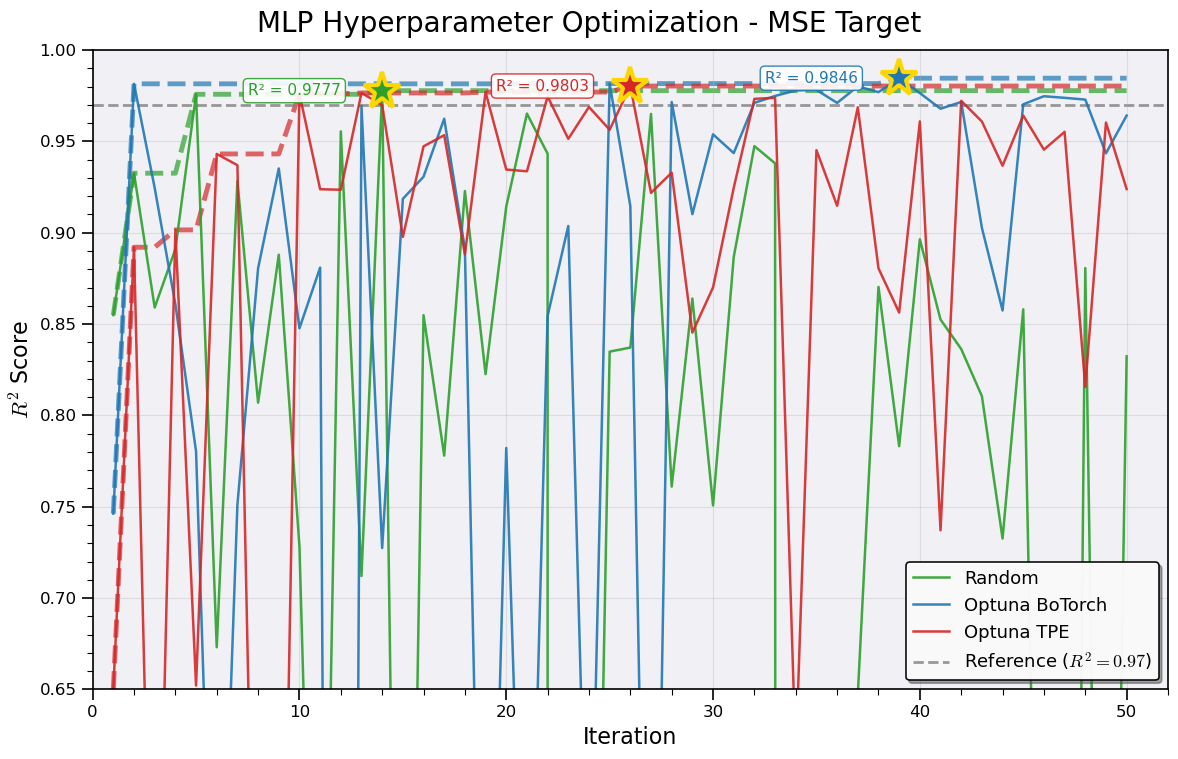

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

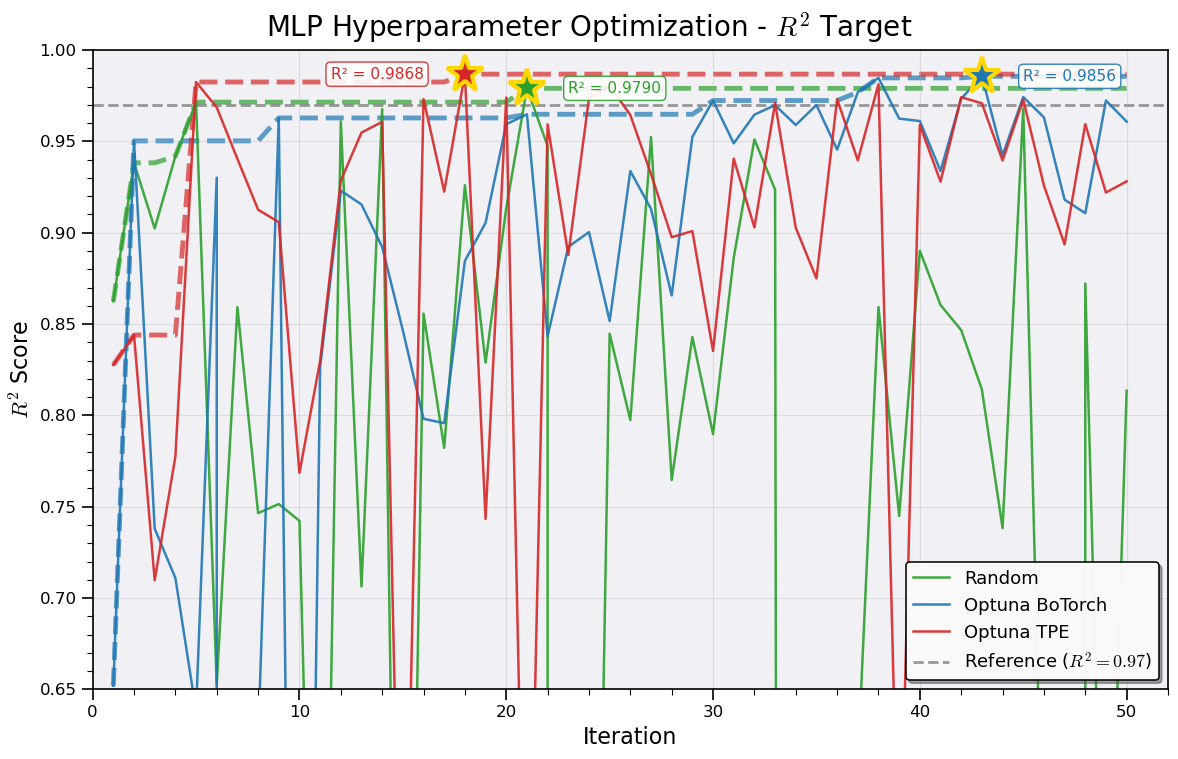


✅ Individual LaTeX-formatted convergence plots created!


In [11]:
# =============================================================================
# INDIVIDUAL LATEX-FORMATTED CONVERGENCE PLOTS FOR MSE AND R² TARGETS
# =============================================================================
print("\n🎨 Creating individual LaTeX-formatted convergence plots for MSE and R² targets...")
print("=" * 70)

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# Configure matplotlib for LaTeX-style rendering (matching reference style)
plt.rcParams.update({
    'text.usetex': False,  # Keep False to avoid LaTeX installation issues
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.titlesize': 20,
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
    'patch.linewidth': 0.8,
    'axes.grid': True,
    'grid.linewidth': 0.8,
    'mathtext.fontset': 'cm',  # Computer Modern math font
    'mathtext.rm': 'serif',
})

# Color and label mapping
method_colors = {
    'Random': '#2ca02c',      # Green
    'BoTorch': '#1f77b4',    # Blue
    'TPE': '#d62728'         # Red
}
method_labels = {
    'Random': 'Random',
    'BoTorch': 'Optuna BoTorch',
    'TPE': 'Optuna TPE'
}

# --- MSE Optimization Target ---
fig_mse, ax_mse = plt.subplots(1, 1, figsize=(12, 8))
fig_mse.suptitle(r'MLP Hyperparameter Optimization - MSE Target', fontsize=20, y=0.95)
for study_name in ['Random_mse', 'BoTorch_mse', 'TPE_mse']:
    if study_name in optimization_results:
        data = optimization_results[study_name]
        sampler = data['sampler']
        color = method_colors.get(sampler, '#333333')
        label = method_labels.get(sampler, sampler)
        r2_scores = data['r2_evolution']
        iterations = data['iterations']
        # Calculate running max
        running_max = []
        current_max = r2_scores[0]
        for score in r2_scores:
            if score > current_max:
                current_max = score
            running_max.append(current_max)
        # Plot actual
        ax_mse.plot(iterations, r2_scores,
                    color=color,
                    linewidth=1.8,
                    label=label,
                    alpha=0.9,
                    zorder=2,
                    linestyle='-')
        # Plot running max
        ax_mse.plot(iterations, running_max,
                    color=color,
                    linewidth=3.5,
                    alpha=0.7,
                    zorder=1,
                    linestyle='--')
        # Highlight max R²
        max_r2 = max(r2_scores)
        max_iteration = iterations[r2_scores.index(max_r2)]
        ax_mse.plot(max_iteration, max_r2,
                    marker='*', markersize=28,
                    color=color,
                    markeredgecolor='gold',
                    markeredgewidth=3,
                    zorder=10)
        # Annotate left of star
        ax_mse.text(max_iteration - 2, max_r2,
                    f'R² = {max_r2:.4f}',
                    fontsize=11,
                    color=color,
                    ha='right', va='center',
                    bbox=dict(boxstyle='round,pad=0.3',
                             facecolor='white',
                             edgecolor=color,
                             alpha=0.9,
                             linewidth=1),
                    zorder=11)
# Reference line
ax_mse.axhline(y=0.97, color='gray', linestyle='--', linewidth=2, alpha=0.8,
               label=r'Reference ($R^2 = 0.97$)', zorder=1)
ax_mse.set_xlabel(r'Iteration', fontsize=16)
ax_mse.set_ylabel(r'$R^2$ Score', fontsize=16)
ax_mse.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
ax_mse.set_facecolor('#f0f0f5')
legend_mse = ax_mse.legend(frameon=True, fancybox=True, shadow=True,
                          loc='lower right', fontsize=15,
                          framealpha=0.95, edgecolor='black')
legend_mse.get_frame().set_linewidth(1.2)
ax_mse.set_xlim(0, 52)
all_r2_scores = []
for study_name in ['Random_mse', 'BoTorch_mse', 'TPE_mse']:
    if study_name in optimization_results:
        all_r2_scores.extend(optimization_results[study_name]['r2_evolution'])
min_r2 = min(all_r2_scores)
max_r2 = max(all_r2_scores)
padding = (max_r2 - min_r2) * 0.1
ax_mse.set_ylim(max(0.65, min_r2 - padding), min(1.0, max_r2 + padding))
ax_mse.tick_params(which='major', length=8, width=1.2, labelsize=12)
ax_mse.tick_params(which='minor', length=4, width=0.8)
ax_mse.minorticks_on()
for spine in ax_mse.spines.values():
    spine.set_linewidth(1.2)
    spine.set_edgecolor('black')
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# --- R² Optimization Target ---
fig_r2, ax_r2 = plt.subplots(1, 1, figsize=(12, 8))
fig_r2.suptitle(r'MLP Hyperparameter Optimization - $R^2$ Target', fontsize=20, y=0.95)
for study_name in ['Random_r2', 'BoTorch_r2', 'TPE_r2']:
    if study_name in optimization_results:
        data = optimization_results[study_name]
        sampler = data['sampler']
        color = method_colors.get(sampler, '#333333')
        label = method_labels.get(sampler, sampler)
        r2_scores = data['r2_evolution']
        iterations = data['iterations']
        running_max = []
        current_max = r2_scores[0]
        for score in r2_scores:
            if score > current_max:
                current_max = score
            running_max.append(current_max)
        ax_r2.plot(iterations, r2_scores,
                   color=color,
                   linewidth=1.8,
                   label=label,
                   alpha=0.9,
                   zorder=2,
                   linestyle='-')
        ax_r2.plot(iterations, running_max,
                   color=color,
                   linewidth=3.5,
                   alpha=0.7,
                   zorder=1,
                   linestyle='--')
        max_r2 = max(r2_scores)
        max_iteration = iterations[r2_scores.index(max_r2)]
        ax_r2.plot(max_iteration, max_r2,
                   marker='*', markersize=28,
                   color=color,
                   markeredgecolor='gold',
                   markeredgewidth=3,
                   zorder=10)
        # Annotate left of star for TPE, right for others
        if sampler == 'TPE':
            ax_r2.text(max_iteration - 2, max_r2,
                       f'R² = {max_r2:.4f}',
                       fontsize=11,
                       color=color,
                       ha='right', va='center',
                       bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='white',
                                edgecolor=color,
                                alpha=0.9,
                                linewidth=1),
                       zorder=11)
        else:
            ax_r2.text(max_iteration + 2, max_r2,
                       f'R² = {max_r2:.4f}',
                       fontsize=11,
                       color=color,
                       ha='left', va='center',
                       bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='white',
                                edgecolor=color,
                                alpha=0.9,
                                linewidth=1),
                       zorder=11)
ax_r2.axhline(y=0.97, color='gray', linestyle='--', linewidth=2, alpha=0.8,
              label=r'Reference ($R^2 = 0.97$)', zorder=1)
ax_r2.set_xlabel(r'Iteration', fontsize=16)
ax_r2.set_ylabel(r'$R^2$ Score', fontsize=16)
ax_r2.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
ax_r2.set_facecolor('#f0f0f5')
legend_r2 = ax_r2.legend(frameon=True, fancybox=True, shadow=True,
                        loc='lower right', fontsize=15,
                        framealpha=0.95, edgecolor='black')
legend_r2.get_frame().set_linewidth(1.2)
ax_r2.set_xlim(0, 52)
all_r2_scores = []
for study_name in ['Random_r2', 'BoTorch_r2', 'TPE_r2']:
    if study_name in optimization_results:
        all_r2_scores.extend(optimization_results[study_name]['r2_evolution'])
min_r2 = min(all_r2_scores)
max_r2 = max(all_r2_scores)
padding = (max_r2 - min_r2) * 0.1
ax_r2.set_ylim(max(0.65, min_r2 - padding), min(1.0, max_r2 + padding))
ax_r2.tick_params(which='major', length=8, width=1.2, labelsize=12)
ax_r2.tick_params(which='minor', length=4, width=0.8)
ax_r2.minorticks_on()
for spine in ax_r2.spines.values():
    spine.set_linewidth(1.2)
    spine.set_edgecolor('black')
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

print("\n✅ Individual LaTeX-formatted convergence plots created!")

In [4]:
# =============================================================================
# TOTAL OPTIMIZATION TIME FOR EACH MODEL/METHOD
# =============================================================================
print("\n⏱️ Total optimization time for each model/method (seconds):")
print("=" * 60)

for target in ['mse', 'r2']:
    print(f"\n{target.upper()} Optimization Target:")
    for method in ['Random', 'BoTorch', 'TPE']:
        study_name = f"{method}_{target}"
        if study_name in df['study'].unique():
            total_time = df[df['study'] == study_name]['duration'].sum()
            print(f"  {method:8}: {total_time:.2f} seconds")
        else:
            print(f"  {method:8}: No data found")
print("\nDone.")

# Compute total optimization time for each model (6 runs, 50 trials each)
df_total_opt_time = []
n_trials = 50
for i in range(6):
    start = i * n_trials
    end = start + n_trials
    total_time = df.duration.iloc[start:end].sum()
    df_total_opt_time.append(total_time)

print("Total optimization time for each model (seconds):")
for idx, t in enumerate(df_total_opt_time, 1):
    print(f"Model {idx}: {t:.2f} seconds")


⏱️ Total optimization time for each model/method (seconds):

MSE Optimization Target:


TypeError: unsupported format string passed to Timedelta.__format__